# Ride-segment terrain clustering

**Exploratory subproject — not part of the main app.**

The main app classifies every GPX point into `flat` / `climb` / `descent`
purely from local gradient (`|grade| <= 1.5%` -> flat, see
`../src/analysis.js`). That's a good rule for the app's cardio/strength
split, but it collapses a lot of real texture: a smooth open flat road and
a stop-start flat road through junctions both read as "flat".

This notebook asks: if we hand a clustering algorithm richer per-segment
features (gradient texture, speed variability, turn rate, stop-start
behaviour), what categories does the *data* actually support — and do any
of them look like genuinely new, useful categories (e.g. "flat with
obstacles", "rolling/punchy", "steady sustained climb")?

Data: every `.gpx` file in `../GPXExamples`.


In [1]:
# scikit-learn and torch each bundle their own OpenMP runtime (Intel vs
# LLVM); loading both in one process is a known source of crashes on
# macOS (see https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md).
# This env var must be set before numpy/sklearn/torch are imported.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

%matplotlib inline
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import torch
import torch.nn as nn

from gpx_features import load_all_rides, WindowConfig, load_all_routes, RouteWindowConfig, BRAKE_THRESHOLD_MPS2

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RNG = 42


## 1. Load all rides and engineer segment features

Each ride is sliced into non-overlapping 60-second windows. Each window gets a feature vector describing its terrain and riding texture (see `gpx_features.windowed_features` for exact definitions).

In [2]:
GPX_DIR = Path("../../GPXExamples")
combined, point_series = load_all_rides(GPX_DIR, WindowConfig(window_s=60))
print(combined.shape)
combined.head()


(4067, 30)


,ride,segment_idx,start_s,duration_s,distance_m,start_lat,start_lon,end_lat,end_lon,grade_mean,grade_std,grade_abs_mean,grade_sign_changes,elev_gain_m,elev_loss_m,speed_mean_kmh,speed_std_kmh,speed_cv,turn_rate_mean_dps,turn_rate_p90_dps,stop_fraction,brake_p10_mps2,brake_fraction,hr_mean,hr_std,cad_mean,cad_std,power_mean,power_std,atemp_mean
0,100% on Good Cycle Path - in UK!!!,0,0.0,59.0,256.953276,53.806114,-1.440575,53.807833,-1.438804,1.533566,1.056382,1.560836,4,4.016667,0.026667,15.417197,4.613487,0.299243,6.490385,17.305690,0.05,-0.193948,0.00,112.116667,6.651345,48.850000,20.260026,137.440678,79.873881,25.283333
1,100% on Good Cycle Path - in UK!!!,1,60.0,59.0,413.764664,53.807853,-1.438720,53.807406,-1.432560,-0.628859,1.414193,1.114960,2,0.973333,3.880000,25.182695,2.513184,0.099798,3.606961,8.423556,0.00,-0.237169,0.00,129.216667,3.836010,61.150000,27.046617,144.616667,109.886242,26.000000
2,100% on Good Cycle Path - in UK!!!,2,120.0,59.0,506.240552,53.807398,-1.432444,53.805332,-1.425793,-0.817124,0.763607,0.870583,3,0.120000,4.373333,30.834538,2.629482,0.085277,2.503213,5.681815,0.00,-0.158699,0.00,141.316667,2.135191,77.350000,15.556159,180.783333,63.186324,26.000000
3,100% on Good Cycle Path - in UK!!!,3,180.0,59.0,406.914974,53.805301,-1.425669,53.804638,-1.419737,3.443893,4.203401,4.667839,2,12.853333,3.413333,24.945414,7.361240,0.295094,2.125962,4.893022,0.00,-0.230551,0.05,146.833333,3.599278,71.850000,9.642464,286.883333,119.904636,26.000000
4,100% on Good Cycle Path - in UK!!!,4,240.0,59.0,323.976674,53.804608,-1.419680,53.802020,-1.421381,1.436427,1.752507,1.852437,3,5.040000,0.746667,19.739423,1.705910,0.086421,3.284637,8.413209,0.00,-0.041349,0.00,157.416667,1.062323,58.733333,23.901540,199.733333,98.488727,26.000000


## 2. Rides and segment counts

In [3]:
summary = (
    combined.groupby("ride")
    .agg(
        segments=("segment_idx", "count"),
        distance_km=("distance_m", lambda s: s.sum() / 1000),
        duration_min=("duration_s", lambda s: s.sum() / 60),
        avg_grade_abs=("grade_abs_mean", "mean"),
        avg_stop_fraction=("stop_fraction", "mean"),
    )
    .round(2)
    .sort_values("distance_km", ascending=False)
)
summary


,segments,distance_km,duration_min,avg_grade_abs,avg_stop_fraction
ride,,,,,
Ronde Van Vlaanderen 2022,600,250.92,573.90,2.79,0.03
L’Etape 2022,616,161.89,579.13,5.93,0.02
Tour of Flanders Sportive 2026,448,158.07,421.73,3.45,0.06
L’Etape 2023 Annemasse to Morzine,561,152.84,539.42,6.06,0.02
L’Etape 2024,584,142.18,560.78,5.71,0.02
GVC Yorkshire Wolds,386,139.61,363.95,2.72,0.03
Afternoon Ride,139,62.31,136.43,1.62,0.01
Ronde van Elmet Cyclepaths - well 98%,134,49.03,129.27,1.85,0.03
Gvc Tuesday,96,41.66,91.58,1.75,0.01


## 3. Feature distributions

A quick look at the spread of the core engineered features across all segments, all rides pooled.

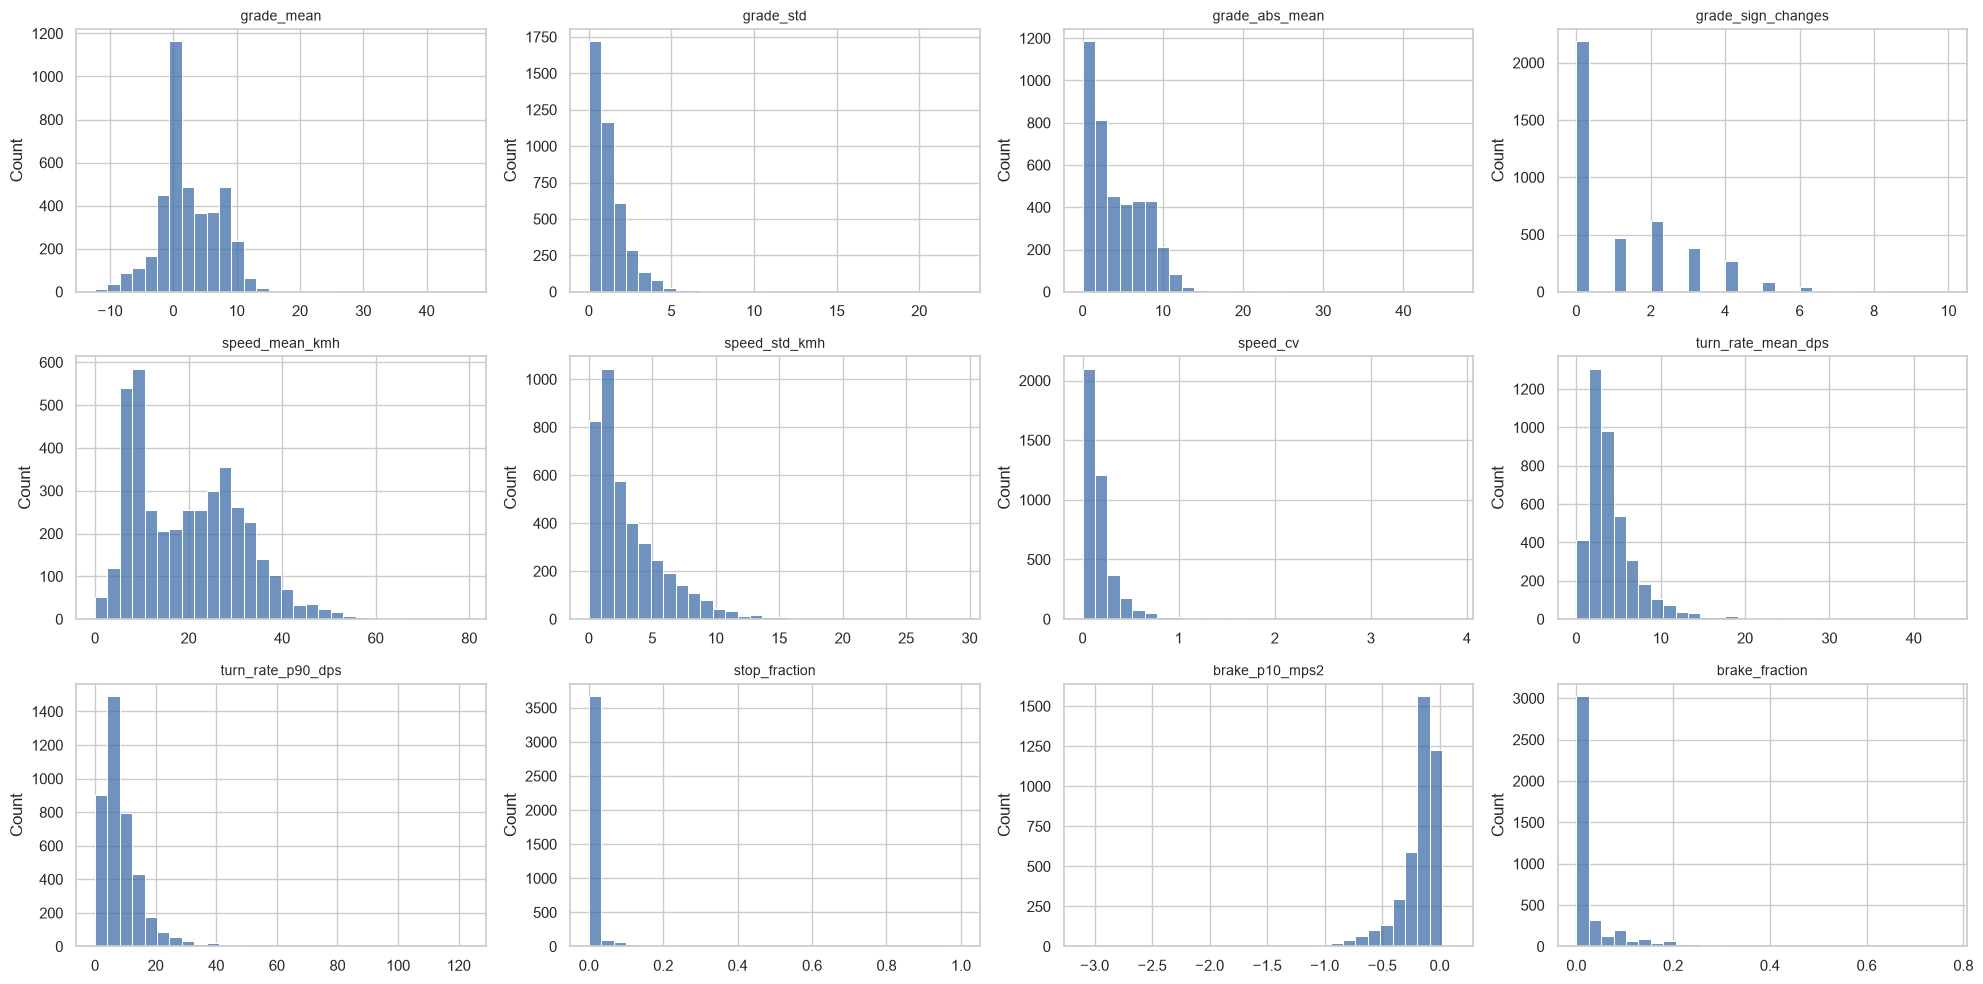

In [4]:
CORE_FEATURES = [
    "grade_mean", "grade_std", "grade_abs_mean", "grade_sign_changes",
    "speed_mean_kmh", "speed_std_kmh", "speed_cv",
    "turn_rate_mean_dps", "turn_rate_p90_dps", "stop_fraction",
    "brake_p10_mps2", "brake_fraction",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), CORE_FEATURES):
    sns.histplot(combined[col], bins=30, ax=ax, color="#3f6fa8")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
fig.tight_layout()


## 4. Correlation between features

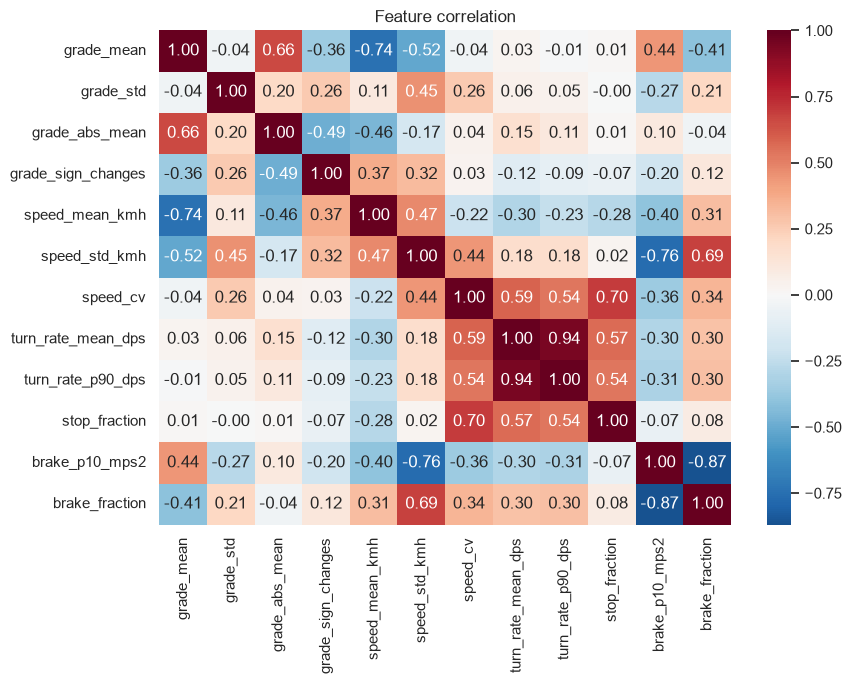

In [5]:
corr = combined[CORE_FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature correlation")
fig.tight_layout()


## 5. Standardise features for clustering

`CORE_FEATURES` above are used for clustering because every ride has
them — heart rate/cadence/power are missing for some rides/segments (e.g.
the walk has no cadence, some rides have no power meter), so they're kept
aside for validating clusters afterwards rather than driving the
clustering itself.

Segment *counts* are heavily imbalanced across rides now that several
multi-hour mountain sportives are in the set — the three L'Etape rides
alone are ~60% of all 2,942 segments. Fitting the scaler/clusterer on the
raw pooled segments would make every downstream step (`best_k`,
centroids) mostly describe Alpine climbing texture rather than "what
terrain textures exist across this whole set". So scaling and clustering
below are fit on a per-ride-capped sample; every segment (including the
uncapped rest) is then labelled by transforming/predicting through that
fitted scaler/model.


In [6]:
MAX_SEGMENTS_PER_RIDE = 150

fit_sample = (
    combined.groupby("ride", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_SEGMENTS_PER_RIDE), random_state=RNG))
)
print("segments used to fit scaler/clusterer:", fit_sample.shape[0], "of", combined.shape[0])

scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(fit_sample[CORE_FEATURES].to_numpy())
X_scaled = scaler.transform(combined[CORE_FEATURES].to_numpy())
X_scaled.shape


segments used to fit scaler/clusterer: 1772 of 4067


(4067, 12)

## 6. PCA — a 2D look at the feature space

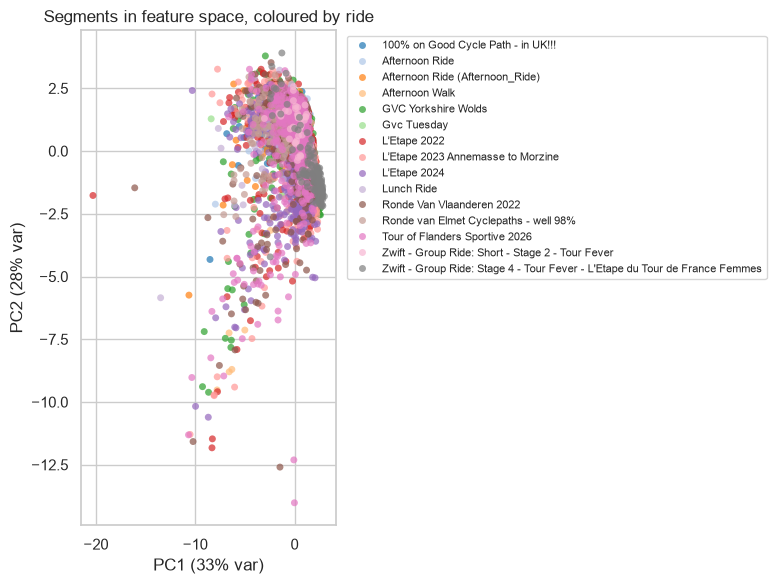

In [7]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

# tab10 only has 10 distinct hues; this set now has 12 rides, so a fixed
# "tab10" string would silently repeat colours across two rides.
ride_palette = sns.color_palette("tab20", combined["ride"].nunique())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=combined["ride"], ax=ax,
    palette=ride_palette, s=25, alpha=0.7, linewidth=0,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("Segments in feature space, coloured by ride")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()


## 7. Choosing k for KMeans (elbow + silhouette)

Sweeping k rather than assuming a number of categories up front — the whole point is to let the data say how many distinct terrain textures there are.

best_k by silhouette (fit on the per-ride-capped sample): 2


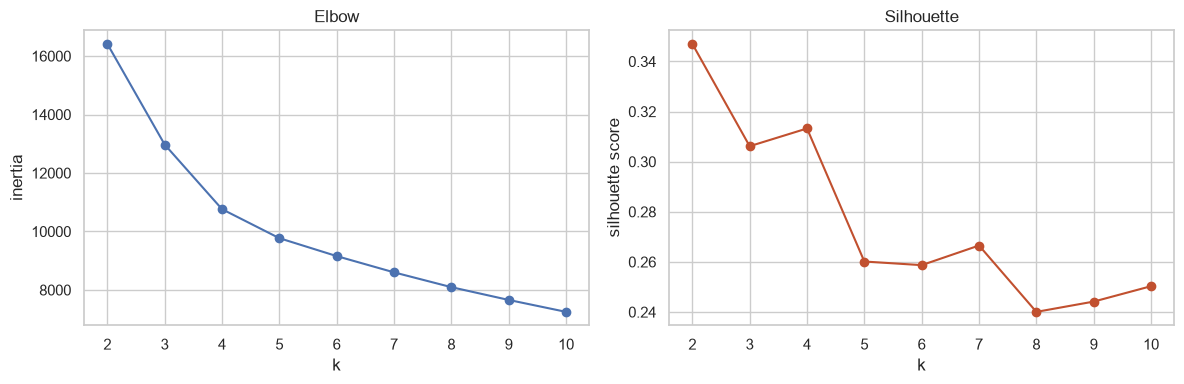

In [8]:
k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    labels = km.fit_predict(X_fit_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_fit_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow")
axes[1].plot(list(k_range), silhouettes, "o-", color="#c1502f")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette")
fig.tight_layout()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("best_k by silhouette (fit on the per-ride-capped sample):", best_k)


## 8. Fit KMeans with the chosen k and inspect cluster centroids

In [9]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RNG)
kmeans.fit(X_fit_scaled)
combined["cluster"] = kmeans.predict(X_scaled)  # label every segment, not just the capped fitting sample

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=CORE_FEATURES)
centroid_df["n_segments"] = combined["cluster"].value_counts().sort_index().values
centroid_df.round(2)


,grade_mean,grade_std,grade_abs_mean,grade_sign_changes,speed_mean_kmh,speed_std_kmh,speed_cv,turn_rate_mean_dps,turn_rate_p90_dps,stop_fraction,brake_p10_mps2,brake_fraction,n_segments
0,3.04,1.08,3.90,1.13,19.51,2.16,0.12,3.14,6.56,0.01,-0.12,0.01,3146
1,-0.61,1.81,2.88,2.16,24.59,6.91,0.37,7.10,15.92,0.07,-0.41,0.11,921


## 9. Hand-labelling clusters from their centroid profile

A simple, transparent rule-based labeller over the *centroid* values (not
the raw data) — it turns each cluster's characteristic shape into a
human-readable name. Treat these labels as a first-pass starting point to
refine by eye against section 11's plots, not a final taxonomy.


In [10]:
def label_cluster(row, medians):
    grade = row["grade_abs_mean"]
    grade_signed = row["grade_mean"]
    turny = row["turn_rate_mean_dps"] > medians["turn_rate_mean_dps"]
    # A stop_fraction *cluster mean* of even ~0.1-0.2 is a lot (it's an
    # average over many windows, most of which have stop_fraction 0), so
    # this stays an absolute floor rather than "above the median" — with
    # only 3-4 clusters the median is a weak reference point.
    stoppy = row["stop_fraction"] > 0.1
    # Same reasoning for braking: scrubbing speed hard through part of a
    # window is the signature of a technical descent that never drops
    # below the stop_fraction floor and may not even turn much (a fast,
    # straight-ish hairpin approach still means heavy braking).
    braky = row["brake_fraction"] > 0.05
    choppy = row["grade_sign_changes"] > medians["grade_sign_changes"]
    fast = row["speed_mean_kmh"] > medians["speed_mean_kmh"]
    # Obstacles/interruptions (junctions, hairpins, traffic) show up as
    # turniness, stopping, or braking *regardless* of whether the segment
    # is flat, climbing, or descending — a technical hairpin climb and a
    # stop-start flat commute share that texture even though their
    # gradient differs completely.
    interrupted = turny or stoppy or braky

    if grade < 1.0:
        return "Flat with obstacles" if interrupted else "Flat, steady"
    if grade_signed <= -1.5:
        if interrupted:
            return "Technical / interrupted descent"
        return "Fast descent" if fast else "Cautious descent"
    if grade_signed >= 1.5:
        if interrupted:
            return "Technical / interrupted climb"
        return "Rolling / punchy climbing" if choppy else "Sustained climb"
    return "Rolling terrain with obstacles" if interrupted else "Rolling terrain"

medians = centroid_df[CORE_FEATURES].median()
centroid_df["label"] = centroid_df.apply(label_cluster, axis=1, medians=medians)
label_map = centroid_df["label"].to_dict()
combined["cluster_label"] = combined["cluster"].map(label_map)

centroid_df[["label", "n_segments", "grade_mean", "grade_abs_mean",
             "grade_sign_changes", "speed_mean_kmh", "turn_rate_mean_dps",
             "stop_fraction", "brake_fraction"]].round(2)


,label,n_segments,grade_mean,grade_abs_mean,grade_sign_changes,speed_mean_kmh,turn_rate_mean_dps,stop_fraction,brake_fraction
0,Sustained climb,3146,3.04,3.90,1.13,19.51,3.14,0.01,0.01
1,Rolling terrain with obstacles,921,-0.61,2.88,2.16,24.59,7.10,0.07,0.11


In [11]:
combined["cluster_label"].value_counts()


cluster_label
Sustained climb                   3146
Rolling terrain with obstacles     921
Name: count, dtype: int64

### 9b. A finer-grained view for comparison

`best_k` is chosen purely by silhouette score, which — given this
particular GPX set is dominated by mountain sportives — tends to land on a
coarse split by climb intensity rather than by riding *texture*. Refitting
at a deliberately higher k shows whether finer categories (like the
"interrupted vs sustained" distinction the labeller above can already
express) are latent in the data even where they don't win on silhouette
alone. Not used elsewhere in the notebook — purely a sanity check to look
at before trusting `best_k`.


In [12]:
FINER_K = 6
km_fine = KMeans(n_clusters=FINER_K, n_init=10, random_state=RNG)
fine_labels = km_fine.fit_predict(X_fit_scaled)
fine_centroids = pd.DataFrame(scaler.inverse_transform(km_fine.cluster_centers_), columns=CORE_FEATURES)
fine_centroids["n_segments"] = pd.Series(fine_labels).value_counts().sort_index().values
fine_medians = fine_centroids[CORE_FEATURES].median()
fine_centroids["label"] = fine_centroids.apply(label_cluster, axis=1, medians=fine_medians)

fine_centroids[["label", "n_segments", "grade_mean", "grade_abs_mean",
                "grade_sign_changes", "speed_mean_kmh", "turn_rate_mean_dps",
                "stop_fraction", "brake_fraction"]].round(2).sort_values("n_segments", ascending=False)


,label,n_segments,grade_mean,grade_abs_mean,grade_sign_changes,speed_mean_kmh,turn_rate_mean_dps,stop_fraction,brake_fraction
4,Rolling terrain,576,0.42,1.40,1.12,24.54,2.58,0.00,0.01
5,Sustained climb,469,7.89,7.89,0.05,9.21,3.92,0.00,0.00
1,Rolling terrain,465,-0.22,2.36,2.86,28.07,3.54,0.00,0.03
2,Rolling terrain with obstacles,194,-1.21,2.98,2.13,25.50,6.91,0.04,0.17
0,Technical / interrupted climb,52,3.27,4.62,0.63,5.98,11.19,0.35,0.05
3,Rolling terrain with obstacles,16,-0.93,2.07,0.37,3.86,27.43,0.63,0.12


### 9c. Per-segment rule labels (not just cluster centroids)

Both `best_k` (2, after adding the braking features) and the finer `k=6`
view only surface a handful of *centroids* — an individual segment then
inherits whichever centroid's label it's nearest to, which is how a real
technical descent can still get filed under "Rolling terrain" once
outnumbered by faster, smoother neighbours in the same cluster.

Applying `label_cluster` directly to every raw segment (using the whole
dataset's feature medians rather than a cluster centroid) sidesteps that:
each segment is classified on its own values, so all four macro terrains
— flat, rolling, climbing, descending — get both a smooth variant and an
obstacles/interrupted variant, independent of how KMeans happened to draw
its boundaries. Section 11 below picks its example rides from these
labels.


In [13]:
medians_all = combined[CORE_FEATURES].median()
combined["raw_label"] = combined.apply(label_cluster, axis=1, medians=medians_all)
print(combined["raw_label"].value_counts())
pd.crosstab(combined["ride"], combined["raw_label"])


raw_label
Technical / interrupted climb      1149
Sustained climb                     635
Flat, steady                        467
Technical / interrupted descent     433
Rolling terrain                     375
Rolling terrain with obstacles      319
Flat with obstacles                 314
Rolling / punchy climbing           209
Fast descent                        154
Cautious descent                     12
Name: count, dtype: int64


raw_label,Cautious descent,Fast descent,Flat with obstacles,"Flat, steady",Rolling / punchy climbing,Rolling terrain,Rolling terrain with obstacles,Sustained climb,Technical / interrupted climb,Technical / interrupted descent
ride,,,,,,,,,,
100% on Good Cycle Path - in UK!!!,0,4,8,5,6,11,15,1,10,3
Afternoon Ride,0,4,12,40,11,32,20,5,7,8
Afternoon Ride (Afternoon_Ride),0,0,18,9,3,6,26,1,11,8
Afternoon Walk,9,0,8,11,7,14,9,7,10,14
GVC Yorkshire Wolds,0,31,28,89,39,65,20,52,32,30
Gvc Tuesday,0,2,7,22,6,28,14,7,5,5
Lunch Ride,0,5,10,8,8,11,14,4,9,9
L’Etape 2022,1,17,9,30,18,28,11,167,257,78
L’Etape 2023 Annemasse to Morzine,0,19,5,32,22,17,12,155,220,79


## 10. Cross-checking with a PyTorch autoencoder embedding

If a completely different, nonlinear representation of the same segments (learned by a small autoencoder) clusters similarly to the hand-crafted features above, that's evidence the categories are a real structure in the data rather than an artefact of which features we picked.

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim, bottleneck=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 8), nn.ReLU(),
            nn.Linear(8, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 8), nn.ReLU(),
            nn.Linear(8, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


torch.manual_seed(RNG)
X_t = torch.tensor(X_scaled, dtype=torch.float32)

model = Autoencoder(in_dim=X_t.shape[1], bottleneck=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    recon, _ = model(X_t)
    loss = loss_fn(recon, X_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"final reconstruction MSE: {losses[-1]:.4f}")


final reconstruction MSE: 0.4004


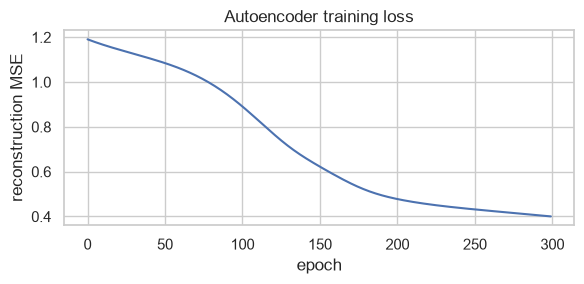

In [15]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("reconstruction MSE")
plt.title("Autoencoder training loss")
plt.tight_layout()


In [16]:
model.eval()
with torch.no_grad():
    _, embedding = model(X_t)
embedding = embedding.numpy()

km_embed = KMeans(n_clusters=best_k, n_init=10, random_state=RNG)
embed_labels = km_embed.fit_predict(embedding)

ari = adjusted_rand_score(combined["cluster"], embed_labels)
print(f"Adjusted Rand Index between feature-space and autoencoder-embedding clusterings: {ari:.3f}")
print("(1.0 = identical clustering, 0.0 = no better than random)")


Adjusted Rand Index between feature-space and autoencoder-embedding clusterings: 0.469
(1.0 = identical clustering, 0.0 = no better than random)


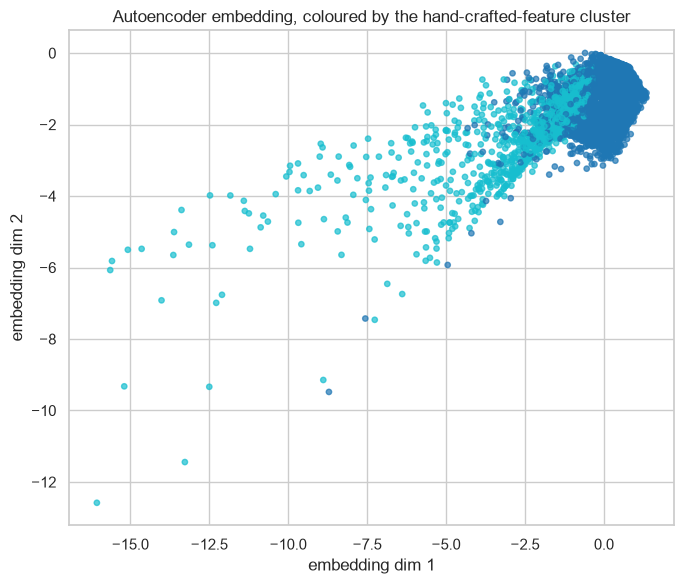

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=combined["cluster"], cmap="tab10", s=15, alpha=0.7)
ax.set_xlabel("embedding dim 1")
ax.set_ylabel("embedding dim 2")
ax.set_title("Autoencoder embedding, coloured by the hand-crafted-feature cluster")
fig.tight_layout()


## 11. Visual sanity check: elevation profile and route map by category

Six contrasting picks, all coloured by section 9c's per-segment `raw_label`
(not the coarse KMeans `cluster_label` — that's down to 2 categories now
that braking is in the mix, which isn't enough to check anything visually):

- flattest and hilliest *outdoor* rides by elevation gain per km,
- a Zwift ride, checked separately (see the note below on why),
- the ride with the widest spread of standardised feature values,
- a ride showing obstacles/braking on relatively flat or rolling terrain
  (junctions, gates, traffic — not a climb or descent),
- a ride showing obstacles/braking on a steep descent (technical hairpins).

The last two are exactly the sub-categories a single macro grade band
(flat/rolling/climbing/descending) can't tell apart on its own — this is
the visual check for whether `raw_label`'s smooth-vs-obstacle split within
each band actually lines up with real terrain, not just numbers in a
table.

Zwift's elevation is physics-simulated rather than GPS-derived, so its
gain-per-km figures run more extreme than any outdoor ride in the set —
picking flattest/hilliest from the pooled set lets Zwift take *both*
slots (confirmed by running this before splitting it out), leaving no
outdoor GPS ride checked at all. Splitting the pick guarantees a look at
both worlds.


In [18]:
is_zwift = combined["ride"].str.contains("Zwift")

outdoor_gain_per_km = combined[~is_zwift].groupby("ride").apply(
    lambda g: g["elev_gain_m"].sum() / (g["distance_m"].sum() / 1000)
)
flat_ride = outdoor_gain_per_km.idxmin()
hilly_ride = outdoor_gain_per_km.idxmax()

zwift_gain_per_km = combined[is_zwift].groupby("ride").apply(
    lambda g: g["elev_gain_m"].sum() / (g["distance_m"].sum() / 1000)
)
zwift_ride = zwift_gain_per_km.idxmax()  # the more eventful of the two Zwift rides

# Widest spread of standardised feature values -> the ride that itself
# mixes the most different textures, rather than being dominated by one
# throughout. Uses the same standardised features clustering runs on, so
# "variation" is comparable across features on very different raw scales
# (e.g. grade % vs speed km/h vs turn rate deg/s).
std_features = pd.DataFrame(X_scaled, columns=CORE_FEATURES, index=combined.index)
feature_variance = std_features.groupby(combined["ride"]).var().sum(axis=1)
already_picked = {flat_ride, hilly_ride, zwift_ride}
varied_ride = feature_variance.drop(index=already_picked, errors="ignore").idxmax()

# Obstacles/braking on relatively flat or rolling ground -- the sub-category
# a pure grade threshold can't see (a junction-heavy commute reads the same
# as a smooth one on gradient alone).
flat_or_rolling_obstacles = combined["raw_label"].isin(
    ["Flat with obstacles", "Rolling terrain with obstacles"]
)
obstacle_flat_counts = combined[flat_or_rolling_obstacles].groupby("ride").size()
already_picked |= {varied_ride}
obstacle_flat_ride = obstacle_flat_counts.drop(index=already_picked, errors="ignore").idxmax()

# Obstacles/braking on a steep descent -- technical hairpins, not a fast
# smooth descent.
descent_obstacle_counts = combined[combined["raw_label"] == "Technical / interrupted descent"].groupby("ride").size()
already_picked |= {obstacle_flat_ride}
obstacle_descent_ride = descent_obstacle_counts.drop(index=already_picked, errors="ignore").idxmax()

print("flattest (outdoor):", flat_ride, round(outdoor_gain_per_km[flat_ride], 1), "m/km")
print("hilliest (outdoor):", hilly_ride, round(outdoor_gain_per_km[hilly_ride], 1), "m/km")
print("zwift check ride:", zwift_ride, round(zwift_gain_per_km[zwift_ride], 1), "m/km")
print("widest feature variation:", varied_ride, round(feature_variance[varied_ride], 1))
print("flat/rolling obstacles:", obstacle_flat_ride, int(obstacle_flat_counts[obstacle_flat_ride]), "segments")
print("technical descent:", obstacle_descent_ride, int(descent_obstacle_counts[obstacle_descent_ride]), "segments")


flattest (outdoor): Afternoon Ride 7.5 m/km
hilliest (outdoor): L’Etape 2024 32.0 m/km
zwift check ride: Zwift - Group Ride: Stage 4 - Tour Fever - L'Etape du Tour de France Femmes 46.4 m/km
widest feature variation: Tour of Flanders Sportive 2026 16.8
flat/rolling obstacles: Ronde Van Vlaanderen 2022 134 segments
technical descent: L’Etape 2023 Annemasse to Morzine 79 segments


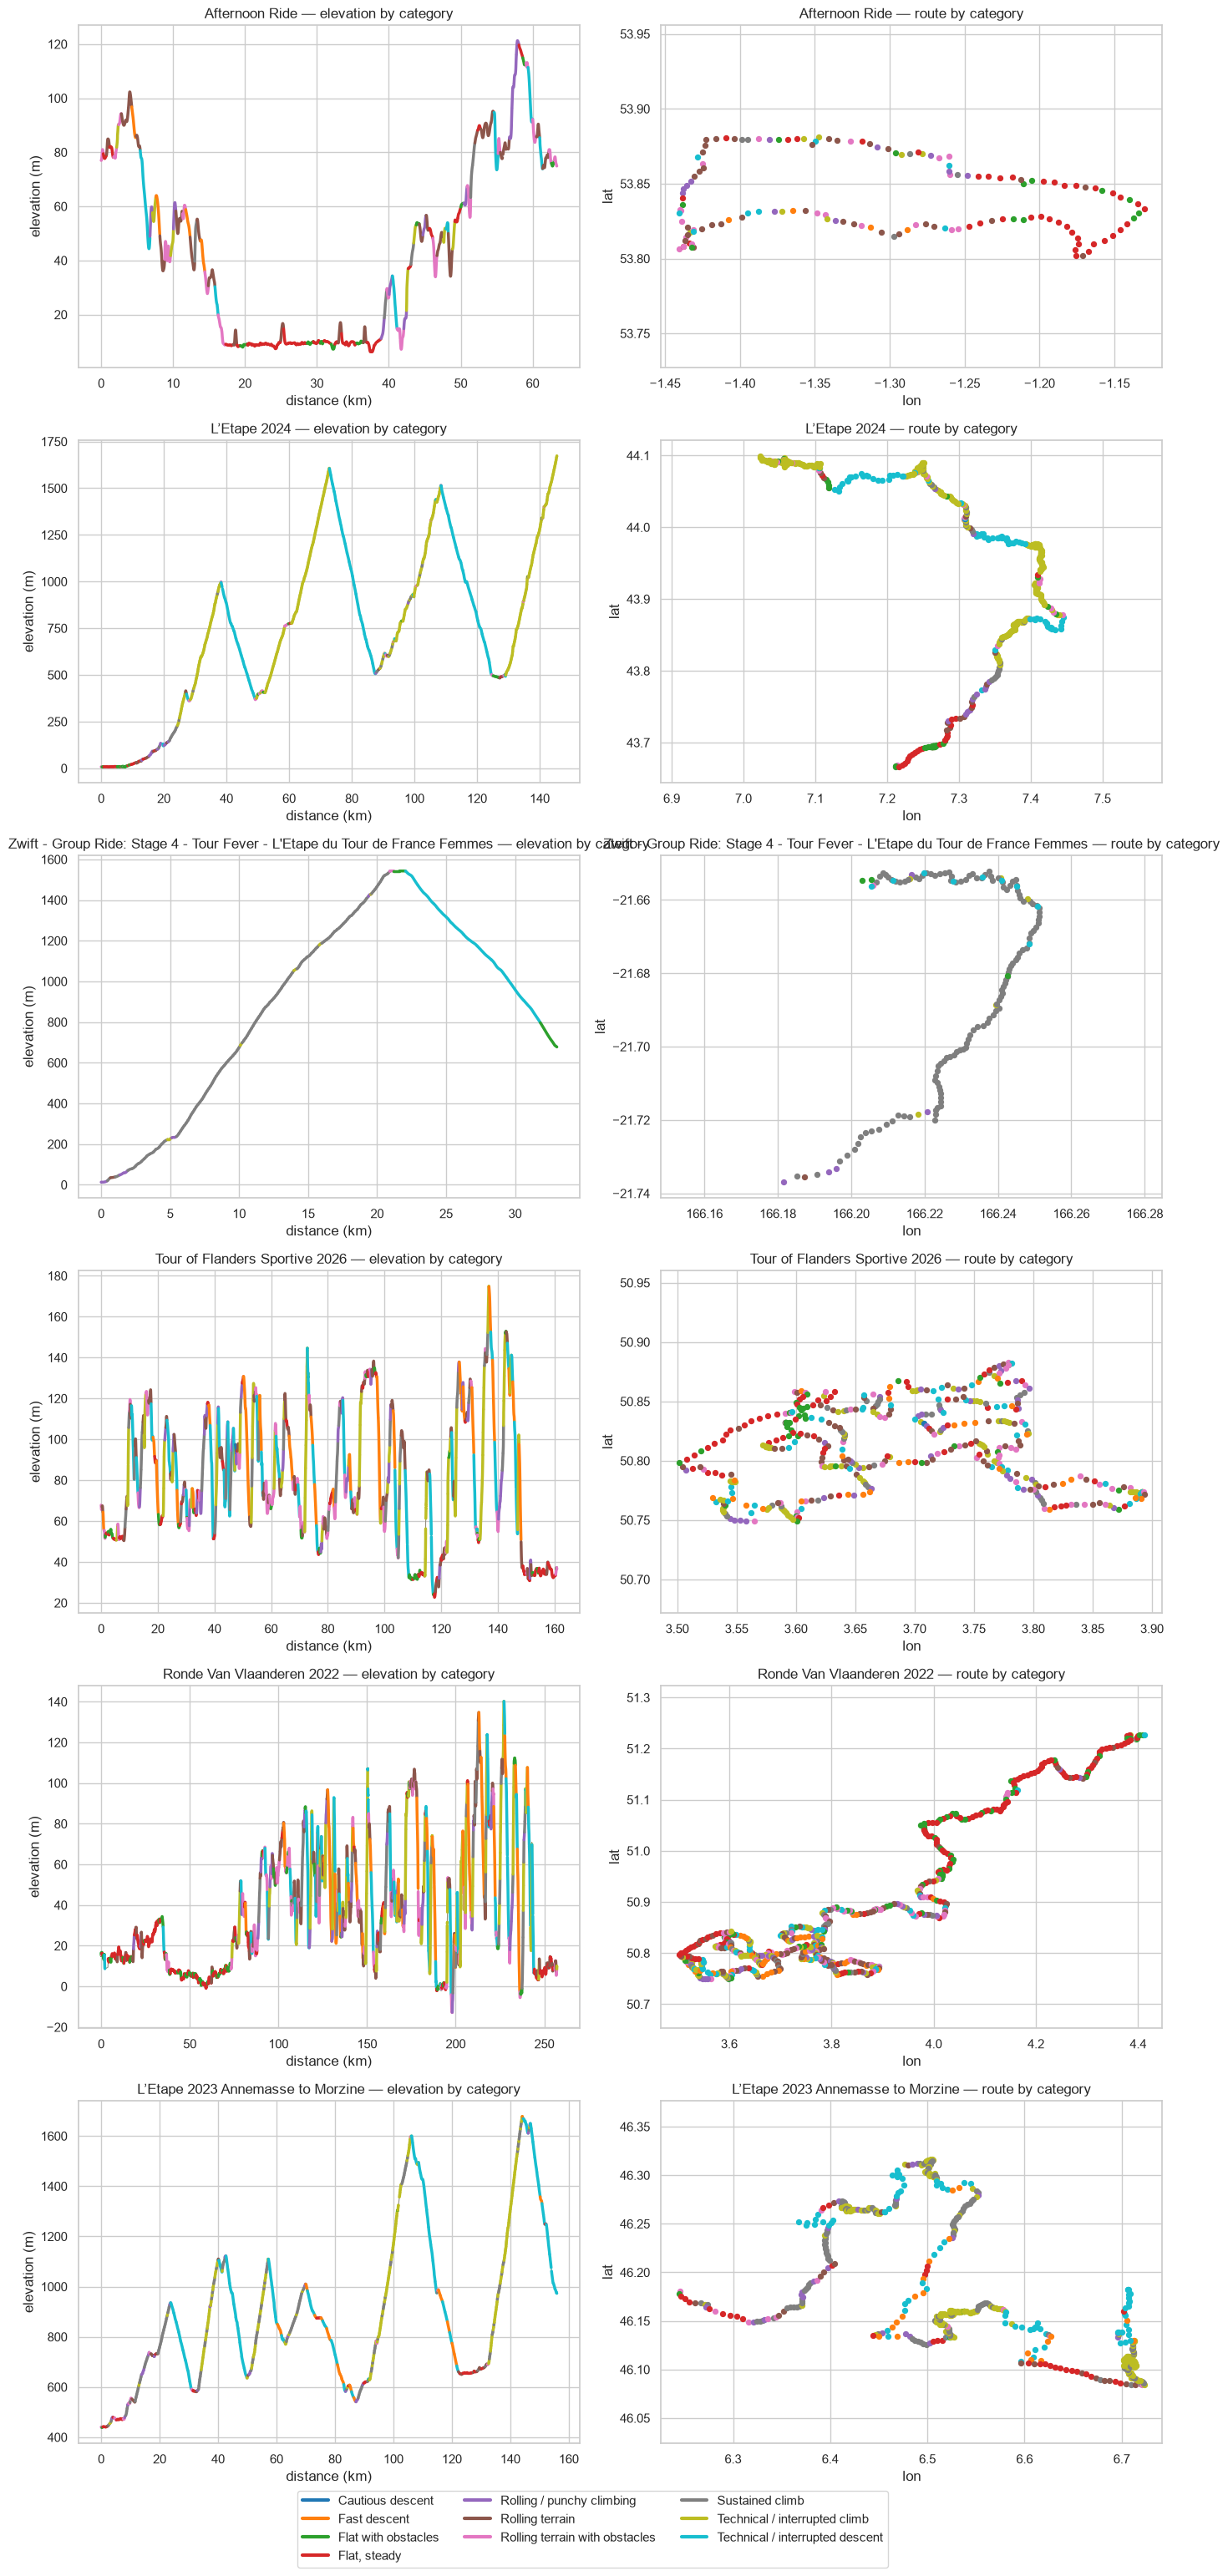

In [19]:
palette = dict(zip(sorted(combined["raw_label"].unique()),
                    sns.color_palette("tab10", combined["raw_label"].nunique())))

def plot_ride(ride_name, ax_elev, ax_map):
    seg = combined[combined["ride"] == ride_name].sort_values("segment_idx")
    pts = point_series[ride_name]

    ax_elev.plot(pts["dist_m"] / 1000, pts["smooth_ele"], color="#948f7f", linewidth=0.8, zorder=1)
    for _, row in seg.iterrows():
        d0 = row["start_s"]
        d1 = d0 + row["duration_s"]
        mask = (pts["t_s"] >= d0) & (pts["t_s"] <= d1)
        ax_elev.plot(pts.loc[mask, "dist_m"] / 1000, pts.loc[mask, "smooth_ele"],
                     color=palette[row["raw_label"]], linewidth=2.5, zorder=2)
    ax_elev.set_title(f"{ride_name} — elevation by category")
    ax_elev.set_xlabel("distance (km)")
    ax_elev.set_ylabel("elevation (m)")

    for _, row in seg.iterrows():
        ax_map.scatter(row["start_lon"], row["start_lat"], color=palette[row["raw_label"]], s=18)
    ax_map.set_title(f"{ride_name} — route by category")
    ax_map.set_xlabel("lon")
    ax_map.set_ylabel("lat")
    ax_map.set_aspect("equal", adjustable="datalim")


fig, axes = plt.subplots(6, 2, figsize=(14, 30))
plot_ride(flat_ride, axes[0, 0], axes[0, 1])
plot_ride(hilly_ride, axes[1, 0], axes[1, 1])
plot_ride(zwift_ride, axes[2, 0], axes[2, 1])
plot_ride(varied_ride, axes[3, 0], axes[3, 1])
plot_ride(obstacle_flat_ride, axes[4, 0], axes[4, 1])
plot_ride(obstacle_descent_ride, axes[5, 0], axes[5, 1])

handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout()


## 12. Save results

In [20]:
out_dir = Path("../output")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "segment_clusters.csv"
combined.to_csv(out_path, index=False)
print("wrote", out_path.resolve(), combined.shape)


wrote /Users/kevinmayfield/github/kevinmayfield/MyPhysicalHealth/segment-analysis/output/segment_clusters.csv (4067, 33)


## 13. Predicting categories for a *planned* route (no ride data)

Everything so far has classified rides that were already ridden and
recorded — every window has real speed, HR, and pacing behaviour to draw
on. A different, arguably more useful question for route planning: can we
predict which parts of a route will be cardio vs. strength vs. technical
*before* riding it, from the route file alone?

`../../GPXRoute` has two Strava **route** exports (not recorded rides) to
test this on. They turn out to be a genuinely different kind of file:

- No `<time>`, no HR/cadence/power at all.
- Points are spaced by *distance* along the route (~25-45m apart, Strava's
  route-simplification spacing), not ~1Hz GPS samples.

Feeding a file like this through `load_all_rides`/`build_point_series`
would hit its "no time" fallback of assuming one point per second —
combined with 25-45m real point spacing, that fabricates speeds of
90-170 km/h out of nothing. So this section uses a separate,
purely-geometric pipeline added to `gpx_features.py`
(`build_route_point_series` / `route_windowed_features` /
`load_all_routes`), windowed by **distance** (1 km) instead of time,
computing only what a route file can actually support:

- gradient (smoothed over distance rather than time, same 40m gradient
  window as everywhere else in this notebook),
- a turn *density* — degrees of bearing change per **metre** instead of
  per second — a speed-independent stand-in for how winding a stretch is.

What this **can't** do: speed, `stop_fraction`, and the braking features
that turned out to matter most for finding technical descents (section
9c/10) all depend on how a specific rider actually rides the road on the
day — traffic, junctions, group behaviour — none of which exists in a
route polyline. So predictions here are a coarser approximation of the
`raw_label` taxonomy, using grade for the macro terrain (flat / rolling /
climbing / descending — this part should be reliable, it's pure
geometry) and turn density as a rough proxy for "technical", rather than
a real obstacle signal. Predicted obstacle/technical labels are marked
with `?` to keep that honest.


In [21]:
ROUTE_DIR = Path("../../GPXRoute")
route_combined, route_point_series = load_all_routes(ROUTE_DIR, RouteWindowConfig(window_m=1000))
print(route_combined.shape)
route_combined.groupby("ride").agg(
    windows=("segment_idx", "count"),
    distance_km=("distance_m", lambda s: s.sum() / 1000),
    elev_gain_m=("elev_gain_m", "sum"),
    avg_grade_abs=("grade_abs_mean", "mean"),
).round(1)


(206, 16)


,windows,distance_km,elev_gain_m,avg_grade_abs
ride,,,,
Ronde Van Vlaanderen 2026,163,152.8,1969.0,0.4
Tour De Adolf and Maria,43,40.6,1484.3,2.9


### 13a. A data-grounded "windy" threshold

Rather than guess a turn-density cutoff, derive it from the real ridden
rides: recompute the same degrees-per-metre quantity from their
`point_series` (already loaded in section 1), bucket it into the same
1km windows the route pipeline uses, and take the median. This keeps the
threshold grounded in this notebook's own data instead of an arbitrary
number.


In [22]:
route_window_m = 1000.0
all_dpm_means = []
for ride, pts in point_series.items():
    dist = pts["dist_m"].to_numpy()
    seg_dist = np.diff(dist, prepend=dist[0])
    turn_dpm = np.divide(pts["turn_deg"].to_numpy(), seg_dist, out=np.zeros(len(pts)), where=seg_dist > 0)
    total_m = dist[-1]
    start = 0.0
    while start < total_m:
        mask = (dist >= start) & (dist < start + route_window_m)
        if mask.sum() >= 3:
            all_dpm_means.append(turn_dpm[mask].mean())
        start += route_window_m

TURN_DPM_THRESHOLD = float(np.median(all_dpm_means))
print(f"windy threshold: median turn density over {len(all_dpm_means)} real-ride 1km windows = {TURN_DPM_THRESHOLD:.2f} deg/m")


windy threshold: median turn density over 1344 real-ride 1km windows = 0.49 deg/m


### 13b. Predict a category per km, from geometry alone

In [23]:
def label_route_segment(row, turn_threshold):
    grade = row["grade_abs_mean"]
    grade_signed = row["grade_mean"]
    windy = row["turn_rate_dpm_mean"] > turn_threshold
    if grade < 1.0:
        return "Flat with obstacles?" if windy else "Flat, steady"
    if grade_signed <= -1.5:
        return "Technical / interrupted descent?" if windy else "Fast descent"
    if grade_signed >= 1.5:
        return "Technical / interrupted climb?" if windy else "Sustained climb"
    return "Rolling terrain with obstacles?" if windy else "Rolling terrain"

route_combined["predicted_label"] = route_combined.apply(label_route_segment, axis=1, turn_threshold=TURN_DPM_THRESHOLD)
route_combined.groupby("ride")["predicted_label"].value_counts()


ride                       predicted_label                 
Ronde Van Vlaanderen 2026  Flat with obstacles?                76
                           Flat, steady                        67
                           Rolling terrain with obstacles?     10
                           Technical / interrupted descent?     3
                           Technical / interrupted climb?       3
                           Rolling terrain                      3
                           Sustained climb                      1
Tour De Adolf and Maria    Technical / interrupted descent?    14
                           Technical / interrupted climb?      11
                           Flat, steady                        10
                           Flat with obstacles?                 7
                           Sustained climb                      1
Name: count, dtype: int64

### 13c. Visual check: predicted elevation profile and route map

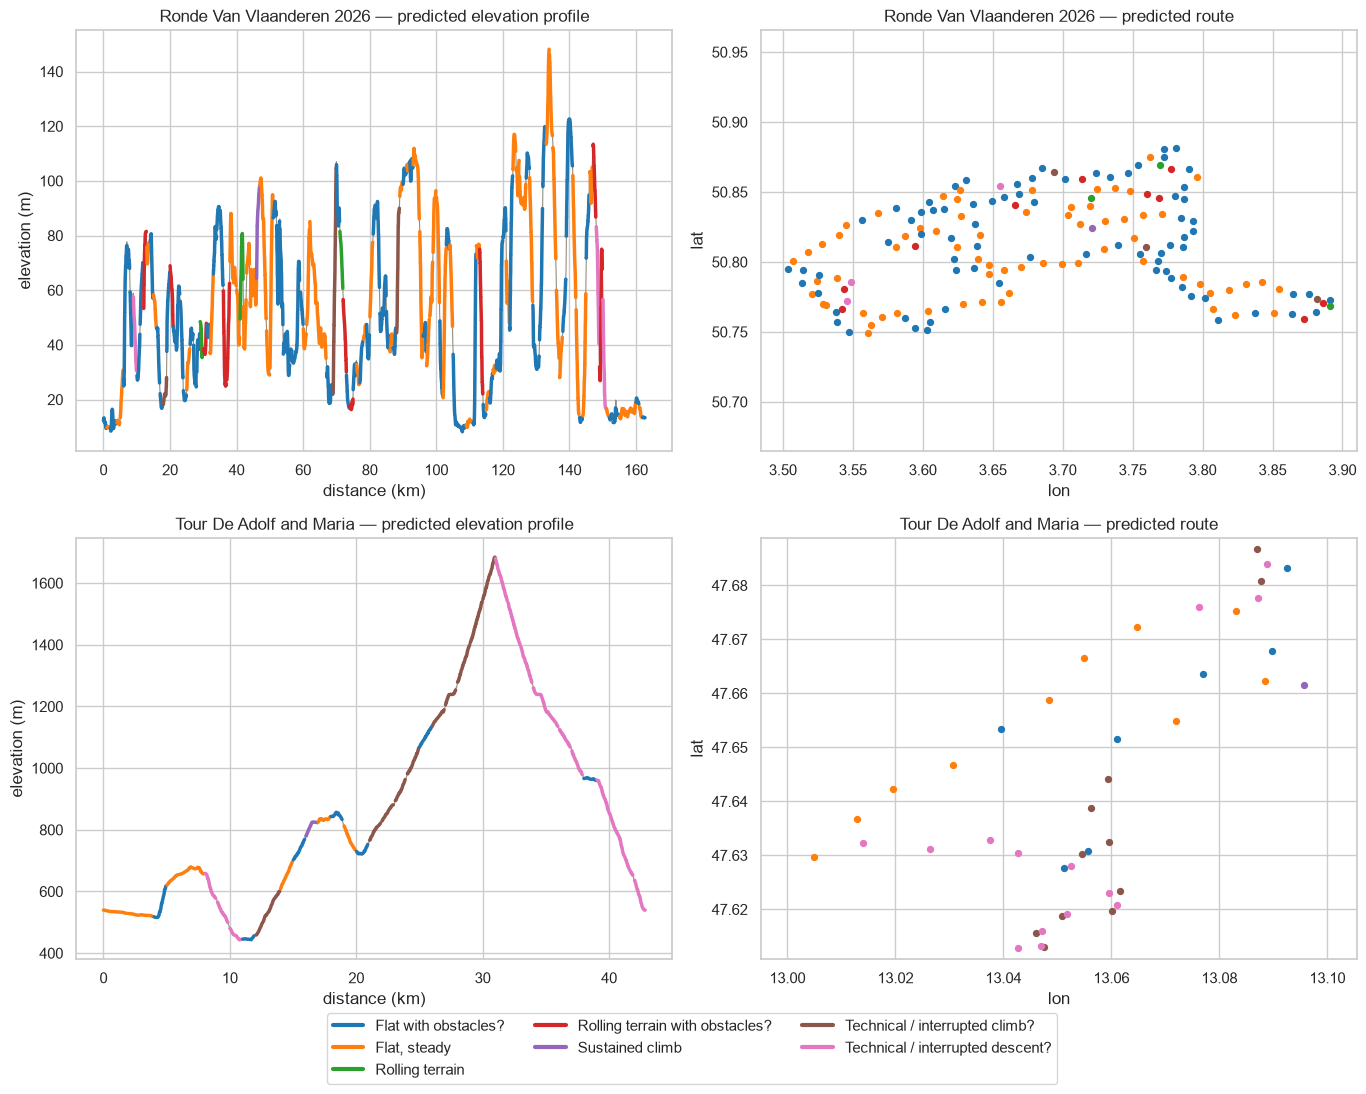

In [24]:
route_palette = dict(zip(sorted(route_combined["predicted_label"].unique()),
                          sns.color_palette("tab10", route_combined["predicted_label"].nunique())))

def plot_route(route_name, ax_elev, ax_map):
    seg = route_combined[route_combined["ride"] == route_name].sort_values("segment_idx")
    pts = route_point_series[route_name]

    ax_elev.plot(pts["dist_m"] / 1000, pts["smooth_ele"], color="#948f7f", linewidth=0.8, zorder=1)
    for _, row in seg.iterrows():
        d0 = row["start_m"]
        d1 = d0 + row["distance_m"]
        mask = (pts["dist_m"] >= d0) & (pts["dist_m"] <= d1)
        ax_elev.plot(pts.loc[mask, "dist_m"] / 1000, pts.loc[mask, "smooth_ele"],
                     color=route_palette[row["predicted_label"]], linewidth=2.5, zorder=2)
    ax_elev.set_title(f"{route_name} — predicted elevation profile")
    ax_elev.set_xlabel("distance (km)")
    ax_elev.set_ylabel("elevation (m)")

    for _, row in seg.iterrows():
        ax_map.scatter(row["start_lon"], row["start_lat"], color=route_palette[row["predicted_label"]], s=18)
    ax_map.set_title(f"{route_name} — predicted route")
    ax_map.set_xlabel("lon")
    ax_map.set_ylabel("lat")
    ax_map.set_aspect("equal", adjustable="datalim")


route_names = sorted(route_combined["ride"].unique())
fig, axes = plt.subplots(len(route_names), 2, figsize=(14, 5 * len(route_names) + 1))
if len(route_names) == 1:
    axes = axes.reshape(1, 2)
for row_i, name in enumerate(route_names):
    plot_route(name, axes[row_i, 0], axes[row_i, 1])

handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in route_palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0))
fig.tight_layout(rect=[0, 0.06, 1, 1])


In [25]:
route_out_path = out_dir / "route_predictions.csv"
route_combined.to_csv(route_out_path, index=False)
print("wrote", route_out_path.resolve(), route_combined.shape)


wrote /Users/kevinmayfield/github/kevinmayfield/MyPhysicalHealth/segment-analysis/output/route_predictions.csv (206, 17)


## 14. Etape case study: predicted vs. actual, and the fatigue gap geometry can't see

Section 13 had no ground truth to check its predictions against — the
`GPXRoute` files have never actually been ridden. The three L'Etape
rides give us the next best thing: real ~9 hour recorded rides, so the
same geometry-only predictor can be run over their *own* GPS tracks and
checked against what actually happened on those exact roads.

These are also long, hard days (~9-9.65 hours), which raises the
question the notebook's route-only predictor has no way to answer:
duration and fatigue change how a rider responds to a given gradient, and
a route file — even a perfect one — can't know that in advance. By the
rider's own account, L'Etape 2022 in particular included a real bonk in
the back half, where HR and power stopped tracking each other normally
and climbing performance fell away. That's used below as a concrete,
data-grounded example of exactly the kind of gap a pre-ride prediction
fundamentally cannot see.


### 14a. Re-slice the real rides into the same 1km windows as section 13

To compare fairly, both the geometry-only prediction and the "actual"
label need to come from the *same* stretches of road. So each Etape
ride's real point series (already loaded in section 1 — full speed, HR,
turn-rate, braking) is re-bucketed into 1km distance windows (not the
60-second time windows used everywhere else in this notebook), producing
two labels per window from the same 1km of road:

- `predicted_label` — grade + turn-density only, exactly `label_route_segment` from section 13, as if this were an unridden route.
- `actual_label` — the full real feature set through `label_cluster` (section 9), i.e. what genuinely happened there.

Real HR/power/cadence, ambient temperature (`atemp`, from the GPX
`<gpxtpx:atemp>` extension — used in section 15), and elapsed ride time
are kept alongside for the fatigue analysis in 14c.


In [26]:
def compare_predicted_vs_actual(ride_name, points, window_m=1000.0):
    dist = points["dist_m"].to_numpy()
    seg_dist = np.diff(dist, prepend=dist[0])
    turn_dpm = np.divide(points["turn_deg"].to_numpy(), seg_dist, out=np.zeros(len(points)), where=seg_dist > 0)
    total_m = dist[-1]

    rows = []
    start, seg_idx = 0.0, 0
    while start < total_m:
        mask = (dist >= start) & (dist < start + window_m)
        if mask.sum() < 3:
            start += window_m
            continue
        w = points.loc[mask]
        grade = w["gradient_pct"].to_numpy()
        speed = w["speed_kmh"].to_numpy()
        turn_rate = w["turn_rate_dps"].to_numpy()
        accel = w["accel_mps2"].to_numpy()
        grade_sign = np.sign(np.where(np.abs(grade) < 1.0, 0, grade))
        sign_changes = np.sum(np.abs(np.diff(grade_sign)) > 0)

        feat = {
            "grade_mean": np.mean(grade), "grade_std": np.std(grade),
            "grade_abs_mean": np.mean(np.abs(grade)), "grade_sign_changes": sign_changes,
            "speed_mean_kmh": np.mean(speed), "speed_std_kmh": np.std(speed),
            "speed_cv": (np.std(speed) / np.mean(speed)) if np.mean(speed) > 0 else 0.0,
            "turn_rate_mean_dps": np.mean(turn_rate), "turn_rate_p90_dps": np.percentile(turn_rate, 90),
            "stop_fraction": float(np.mean(speed < 3.0)),
            "brake_p10_mps2": np.percentile(accel, 10),
            "brake_fraction": float(np.mean(accel < BRAKE_THRESHOLD_MPS2)),
        }
        actual_label = label_cluster(pd.Series(feat), medians_all)
        predicted_label = label_route_segment(pd.Series({
            "grade_mean": feat["grade_mean"],
            "grade_abs_mean": feat["grade_abs_mean"],
            "turn_rate_dpm_mean": turn_dpm[mask].mean(),
        }), TURN_DPM_THRESHOLD)

        rows.append({
            "ride": ride_name, "segment_idx": seg_idx, "start_km": start / 1000,
            "elapsed_hour": w["t_s"].iloc[0] / 3600,
            **feat,
            "hr_mean": w["hr"].mean(), "power_mean": w["power"].mean(), "cad_mean": w["cad"].mean(),
            "atemp_mean": w["atemp"].mean(),
            "actual_label": actual_label, "predicted_label": predicted_label,
        })
        seg_idx += 1
        start += window_m

    return pd.DataFrame(rows)


ETAPE_RIDES = ["L’Etape 2022", "L’Etape 2023 Annemasse to Morzine", "L’Etape 2024"]
etape_compare = pd.concat(
    [compare_predicted_vs_actual(r, point_series[r]) for r in ETAPE_RIDES], ignore_index=True
)
etape_compare["predicted_bare"] = etape_compare["predicted_label"].str.rstrip("?")
etape_compare["match"] = etape_compare["actual_label"] == etape_compare["predicted_bare"]
print(etape_compare.shape)
etape_compare.groupby("ride")["match"].mean().round(2)


(468, 24)


ride
L’Etape 2022                         0.66
L’Etape 2023 Annemasse to Morzine    0.58
L’Etape 2024                         0.90
Name: match, dtype: float64

### 14b. Where predicted and actual disagree — and why it isn't mainly fatigue

Overall agreement is ~69% (2024: 90%, 2022: 66%, 2023: 60%). Before
reaching for a fatigue explanation, check whether mismatches actually
concentrate later in each ride (as fatigue would predict) or are spread
evenly through it.


In [27]:
etape_compare["hour_q"] = etape_compare.groupby("ride")["elapsed_hour"].transform(
    lambda s: pd.qcut(s, 4, labels=False, duplicates="drop")
)
print("match rate by elapsed-hour quartile (0 = first quarter of the ride):")
print(etape_compare.groupby(["ride", "hour_q"])["match"].mean().round(2))
print()
print("confusion matrix, all three Etape rides pooled:")
pd.crosstab(etape_compare["actual_label"], etape_compare["predicted_label"])


match rate by elapsed-hour quartile (0 = first quarter of the ride):
ride                               hour_q
L’Etape 2022                       0         0.50
                                   1         0.73
                                   2         0.71
                                   3         0.69
L’Etape 2023 Annemasse to Morzine  0         0.51
                                   1         0.46
                                   2         0.62
                                   3         0.74
L’Etape 2024                       0         0.81
                                   1         1.00
                                   2         0.94
                                   3         0.86
Name: match, dtype: float64

confusion matrix, all three Etape rides pooled:


predicted_label,Fast descent,Flat with obstacles?,"Flat, steady",Rolling terrain,Rolling terrain with obstacles?,Sustained climb,Technical / interrupted climb?,Technical / interrupted descent?
actual_label,,,,,,,,
Fast descent,16,0,0,0,0,0,0,1
Flat with obstacles,0,12,1,0,0,0,0,0
"Flat, steady",0,0,31,0,0,0,0,0
Rolling / punchy climbing,0,0,0,0,0,22,19,0
Rolling terrain,0,0,0,26,0,0,0,0
Rolling terrain with obstacles,0,0,0,3,15,0,0,0
Sustained climb,0,0,0,0,0,9,32,0
Technical / interrupted climb,0,0,0,0,0,0,141,0
Technical / interrupted descent,58,0,0,0,0,0,0,82


None of the three rides show a match rate that declines toward the end —
2022 goes 52/73/71/69% across its four quarters (*worst* in the first
quarter), 2023 goes 54/49/62/74% (actually improves), 2024 stays high
throughout (81/97/94/86%). So the disagreement isn't fatigue creeping in
over time. The confusion matrix shows it's structural instead, from two
things the simplified route-only rule genuinely cannot see:

- **`label_route_segment` collapses "Sustained climb" and "Rolling /
  punchy climbing" into one predicted bucket.** The real `label_cluster`
  rule splits climbs on `grade_sign_changes` (`choppy`) — a real,
  ride-specific undulation pattern in the recorded elevation trace, not
  something read off turn density.
- **Turn density is a curviness proxy, not an obstacle proxy.** A chunk
  of real "Technical / interrupted climb" segments come from stopping or
  hard braking (queuing behind other riders, a junction) on a road that
  isn't actually very winding — geometry alone has no way to anticipate
  that.

Both are consistent with section 13's own stated limitation — the
predictor was never expected to see stop/brake-driven obstacles, and
wasn't built with a "choppy" branch at all. This is exactly what that
limitation looks like against real data, not a new finding about
fatigue.


### 14c. So where does duration/fatigue actually show up?

Not in the category labels — in the intensity behind them. Restricting
to climbing windows only (`grade_mean >= 1.5`, so terrain is roughly
comparable) and comparing the first vs. last quarter of each ride's
elapsed time isolates a real physiological signature, not a labelling
artefact.


In [28]:
climb_windows = etape_compare[etape_compare["grade_mean"] >= 1.5].copy()
climb_windows["hour_q"] = climb_windows.groupby("ride")["elapsed_hour"].transform(
    lambda s: pd.qcut(s, 4, labels=False, duplicates="drop")
)
by_quarter = climb_windows.groupby(["ride", "hour_q"]).agg(
    grade_mean=("grade_mean", "mean"),
    speed_kmh=("speed_mean_kmh", "mean"),
    hr=("hr_mean", "mean"),
    power_w=("power_mean", "mean"),
    cadence_rpm=("cad_mean", "mean"),
).round(1)
by_quarter


grade_mean  speed_kmh     hr  power_w  cadence_rpm
ride                              hour_q                                                    
L’Etape 2022                      0              3.3       19.3  159.7    212.1         73.8
                                  1              5.6       11.8  167.2    200.6         65.7
                                  2              6.5       10.5  162.3    181.1         59.0
                                  3              7.5        9.7  156.6    196.1         46.4
L’Etape 2023 Annemasse to Morzine 0              4.5       16.2  151.8    229.2         73.4
                                  1              5.9       12.8  157.5    214.6         67.1
                                  2              5.6       11.9  157.6    188.5         61.8
                                  3              7.8        8.0  150.1    181.3         54.7
L’Etape 2024                      0              5.2       15.3  150.4    213.8         72.2
                                  1              6.2       11.5  158.9    204.7         66.7
                                  2              5.5       12.3  155.1    184.7         66.4
                                  3              6.9        9.4  153.3    194.2         64.2

**L'Etape 2022's climbing cadence drops 37% across the day (73.8 → 46.4
rpm), the steepest decline of the three — vs. 26% for 2023 (73.4 → 54.7)
and just 11% for 2024 (72.2 → 64.2), even though 2024 covers similar
duration and climbing.** All three also show heart rate easing off in
the closing quarter *despite* the climbs getting steeper by then (grade
rising from ~4-5% early to ~7-8% late in every ride) — but 2022 pairs
that HR softening with by far the largest cadence collapse, which is the
more telling signal: a rider grinding a much lower cadence for a given
effort, unable to spin normally, is the textbook mechanical signature of
running out of fuel. 2024's cadence barely moving (72.2 → 64.2) despite
comparable duration and terrain is the control case showing this isn't
just "long rides always look like this" — it's specific to how that
particular day was paced and fuelled.

The plot below makes the same point visually: three different fatigue
trajectories on climbs of comparable difficulty, none of which a
route-only prediction could ever anticipate — pacing and fuelling aren't
in the GPX file.


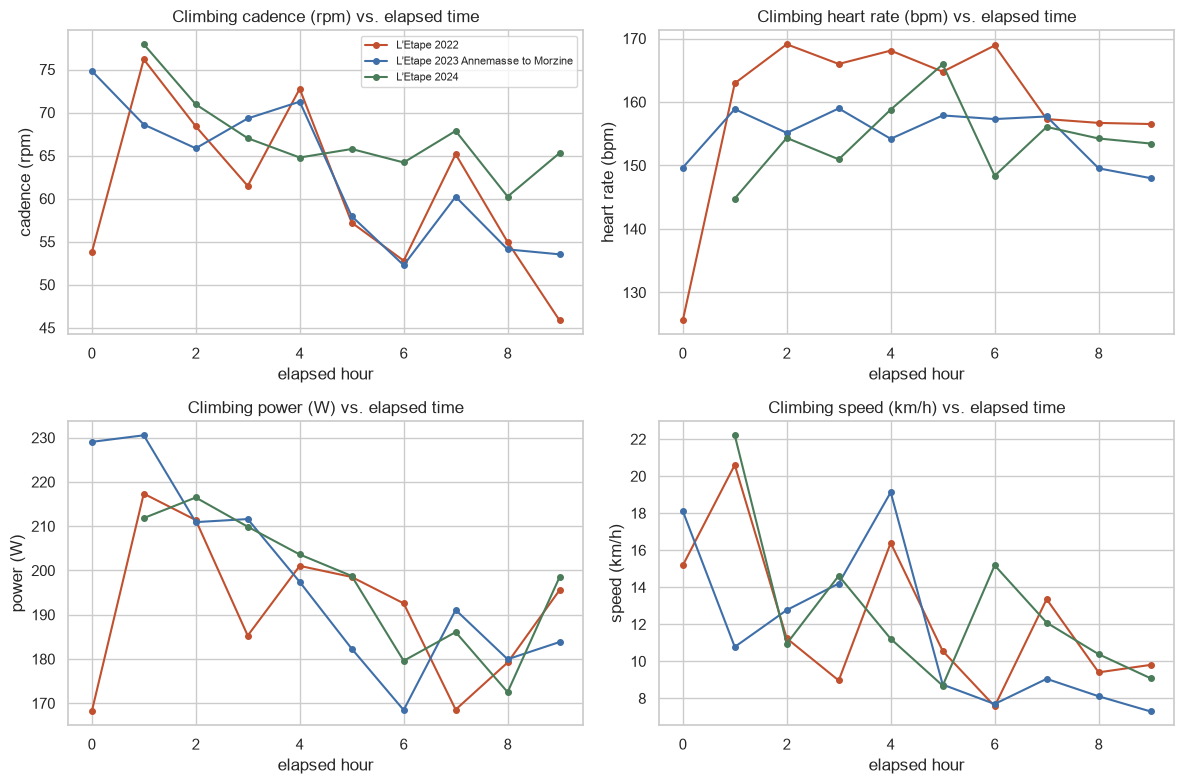

In [29]:
climb_windows["hour_bin"] = np.floor(climb_windows["elapsed_hour"]).clip(upper=9)
binned = climb_windows.groupby(["ride", "hour_bin"]).agg(
    cadence_rpm=("cad_mean", "mean"),
    hr=("hr_mean", "mean"),
    power_w=("power_mean", "mean"),
    speed_kmh=("speed_mean_kmh", "mean"),
).reset_index()

ride_colors = {
    "L’Etape 2022": "#c1502f",
    "L’Etape 2023 Annemasse to Morzine": "#3f6fa8",
    "L’Etape 2024": "#4a7c59",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [("cadence_rpm", "cadence (rpm)"), ("hr", "heart rate (bpm)"),
           ("power_w", "power (W)"), ("speed_kmh", "speed (km/h)")]
for ax, (col, title) in zip(axes.ravel(), metrics):
    for ride, color in ride_colors.items():
        sub = binned[binned["ride"] == ride]
        ax.plot(sub["hour_bin"], sub[col], "o-", color=color, label=ride, markersize=4)
    ax.set_xlabel("elapsed hour")
    ax.set_ylabel(title)
    ax.set_title(f"Climbing {title} vs. elapsed time")

axes[0, 0].legend(fontsize=8, loc="upper right")
fig.tight_layout()


### 14d. Synthesis

Two separate findings, and it matters that they're separate:

1. **Category-level disagreement (section 14b) is a modelling-expressivity
   gap**, not a fatigue effect — the route-only rule is missing branches
   (`choppy`) and signals (stop/braking) that the real rule has. Roughly
   fixable by giving the route predictor more of the real rule's logic.
2. **The fatigue gap (section 14c) is not fixable that way.** Even a
   route-only predictor with every branch of `label_cluster` copied over
   would still call a given climb "Sustained climb" based on its grade —
   correctly — while having no way to know that a rider bonking at hour 9
   will produce barely half the cadence and a *lower*, not higher, heart
   rate on that exact climb than they would at hour 1. That information
   doesn't live in the road; it lives in the rider's pacing and fuelling
   that day. A route preview can flag "this is your hardest climb" — it
   can't flag "and this is also where you're likely to run out of fuel."


## 15. Does temperature explain any of this?

The GPX `<gpxtpx:atemp>` extension (ambient temperature, °C) is present
in almost every outdoor ride in this set — including all three L'Etape
rides — but wasn't being parsed at all until now (`gpx_features.py`'s
`parse_gpx` only read `hr`/`cad`/`power`). Added it as `atemp` on every
point and `atemp_mean` per window, then used it to test two separate
questions: does temperature explain section 14b's predicted-vs-actual
mismatch, and does it explain section 14c's fatigue signature (most
notably 2022's cadence collapse)?


### 15a. A data-quality caveat before trusting the numbers

Bike-computer temperature sensors read air near the device itself, not
true shaded ambient air — at low speed (climbing) there's little airflow
to cool the sensor away from body/road/direct-sun heat, so readings tend
to run hot exactly when a rider is climbing slowly. Worth checking before
treating `atemp` as reliable.


In [30]:
for r in ETAPE_RIDES:
    sub = etape_compare[etape_compare["ride"] == r]
    print(f"{r}: atemp {sub['atemp_mean'].min():.0f}-{sub['atemp_mean'].max():.0f}°C "
          f"(mean {sub['atemp_mean'].mean():.1f}), corr with speed: {sub['atemp_mean'].corr(sub['speed_mean_kmh']):.2f}")


L’Etape 2022: atemp 11-42°C (mean 25.5), corr with speed: -0.15
L’Etape 2023 Annemasse to Morzine: atemp 21-42°C (mean 30.3), corr with speed: -0.25
L’Etape 2024: atemp 18-40°C (mean 25.5), corr with speed: -0.28


Readings up to the low 40s°C on a French Alps stage are implausible as
true shaded-air temperature — that's the sensor-heating effect, not
genuine weather. The speed correlation is weak-to-moderate negative
(slower → hotter reading) across all three rides, consistent with that
artefact but not overwhelming. **Treat absolute `atemp` values with
scepticism; treat the relative trend across a ride (warmer in the valley,
cooler at altitude, rising through the morning) as more trustworthy.**


### 15b. Is temperature behind the section 14b mismatch?

If heat-driven fatigue were pushing real riding behaviour further from
what geometry alone predicts, mismatched windows should run *hotter*
than matched ones. Testing that directly with a t-test per ride.


In [31]:
for r in ETAPE_RIDES:
    sub = etape_compare[etape_compare["ride"] == r]
    matched = sub.loc[sub["match"], "atemp_mean"].dropna()
    mismatched = sub.loc[~sub["match"], "atemp_mean"].dropna()
    t, p = stats.ttest_ind(matched, mismatched, equal_var=False)
    print(f"{r}: matched mean {matched.mean():.1f}°C, mismatched mean {mismatched.mean():.1f}°C "
          f"(t={t:.2f}, p={p:.3f})")


L’Etape 2022: matched mean 26.8°C, mismatched mean 23.0°C (t=3.43, p=0.001)
L’Etape 2023 Annemasse to Morzine: matched mean 30.9°C, mismatched mean 29.5°C (t=1.43, p=0.156)
L’Etape 2024: matched mean 25.6°C, mismatched mean 24.7°C (t=1.47, p=0.153)


**No support for the heat-causes-mismatch idea — if anything, the opposite.**
2023 and 2024 show no significant difference (p > 0.15). 2022 *is*
significant (p = 0.001) — but mismatched windows are the *cooler* ones
(23.0°C vs 26.8°C matched), the reverse of what heat-driven fatigue would
predict. This lines up with section 14b's own finding that 2022's worst
match rate was in its *first* quarter (52%) — the coolest part of the
day, before ambient temperature had risen (`atemp` vs elapsed hour:
r=0.63 for 2022). A more plausible explanation than heat is mass-start
congestion: early in a sportive, riders are bunched together, producing
real stop-start/interrupted riding that a geometry-only predictor has no
way to see — cool and crowded, not hot and fatigued.


### 15c. Does temperature explain the section 14c fatigue signature instead?

Different question: not whether temperature explains the *label*
mismatch, but whether it explains the *cadence/HR collapse* itself.
Re-running section 14c's climbing-quarters table with `atemp` added.


In [32]:
by_quarter_temp = climb_windows.groupby(["ride", "hour_q"]).agg(
    grade_mean=("grade_mean", "mean"),
    atemp=("atemp_mean", "mean"),
    speed_kmh=("speed_mean_kmh", "mean"),
    hr=("hr_mean", "mean"),
    power_w=("power_mean", "mean"),
    cadence_rpm=("cad_mean", "mean"),
).round(1)
print(by_quarter_temp)
print()
print("correlations on climbing windows (atemp vs. each metric):")
for r in ETAPE_RIDES:
    sub = climb_windows[climb_windows["ride"] == r]
    print(f"{r}: cadence r={sub['atemp_mean'].corr(sub['cad_mean']):.2f}, "
          f"HR r={sub['atemp_mean'].corr(sub['hr_mean']):.2f}, "
          f"power r={sub['atemp_mean'].corr(sub['power_mean']):.2f}")


                                          grade_mean  atemp  speed_kmh     hr  power_w  cadence_rpm
ride                              hour_q                                                           
L’Etape 2022                      0              3.3   14.3       19.3  159.7    212.1         73.8
                                  1              5.6   23.7       11.8  167.2    200.6         65.7
                                  2              6.5   36.3       10.5  162.3    181.1         59.0
                                  3              7.5   28.5        9.7  156.6    196.1         46.4
L’Etape 2023 Annemasse to Morzine 0              4.5   24.1       16.2  151.8    229.2         73.4
                                  1              5.9   30.1       12.8  157.5    214.6         67.1
                                  2              5.6   39.7       11.9  157.6    188.5         61.8
                                  3              7.8   32.6        8.0  150.1    181.3         54.7


**Mixed, and not the story a naive "heat caused the bonk" hypothesis
would need.** 2022's coolest climbing quarter is *not* where cadence
collapses — its hottest quarter is Q2 (36.3°C, cadence still 59.0rpm);
the cadence craters in Q3 (46.4rpm) after the temperature has already
*dropped* to 28.5°C. The overall correlation is moderately negative
(cadence r=-0.31), but could just as easily reflect that both temperature
and fatigue happen to trend together over a long ride rather than one
causing the other — 2022's HR barely correlates with temperature at all
(r=0.06).

**2023 tells a cleaner heat-stress story** — a real positive HR
correlation (r=0.33) paired with a strong negative power correlation
(r=-0.56) is the textbook signature of cardiovascular drift: more heart
rate for less power output as it gets hotter. It's also the hottest ride
of the three on average (30.3°C mean vs. 25.5°C in both 2022 and 2024).

**2024 (the well-fuelled control) shows the weakest temperature
sensitivity of the three** (cadence r=-0.14, power r=-0.18, HR r=0.20 —
all smaller in magnitude than 2023's) despite covering a similar
temperature range — reinforcing that fuelling/pacing, not ambient
conditions, is what mainly separates a good day from a bad one in this
data.


### 15d. Synthesis

Answering the original question directly: **temperature does not explain
the predicted-vs-actual mismatch** — the one statistically significant
relationship found runs backwards (mismatches are cooler, not hotter),
and the real driver is still section 14b's structural gap plus likely
early-ride congestion.

**Temperature is, however, a real and previously-missing signal for the
*fatigue* question** — just not a clean single-cause explanation. It
lines up well with 2023's power/HR decoupling, but doesn't line up with
the timing of 2022's specific cadence collapse. The honest read is that
temperature is one contributing factor among several (heat stress,
duration, glycogen depletion, pacing decisions) that jointly determine
how a rider's day unfolds — worth carrying as a feature in any future
fatigue model, but not a substitute for the duration-based analysis in
section 14c, and not something a route-only predictor could use anyway
(it depends on the day's weather, not the road).


## 16. Afternoon Ride case study: macro terrain, then cautious/technical sections

Zooming into a single, ordinary ride — `Afternoon_Ride (1).gpx`
specifically (not the plain `Afternoon_Ride.gpx`, which the
ride-name-collision fix in section 1 disambiguated to
`"Afternoon Ride (Afternoon_Ride)"`) — for two different views of the
same route:

- **16a**: the coarse macro-terrain band each segment falls into — flat,
  rolling, climbing, descending — straight from grade thresholds, no
  obstacle/texture sub-split.
- **16b**: the same ride again, this time highlighting only the
  cautious/technical sections (`Cautious descent`, `Technical /
  interrupted climb`, `Technical / interrupted descent` from section 9c's
  `raw_label`) against everything else muted grey, so they stand out
  against the ride's overall shape.


In [33]:
AFTERNOON_RIDE = "Afternoon Ride"

def macro_terrain(row):
    if row["grade_abs_mean"] < 1.0:
        return "Flat"
    if row["grade_mean"] <= -1.5:
        return "Descending"
    if row["grade_mean"] >= 1.5:
        return "Climbing"
    return "Rolling"

combined["macro_terrain"] = combined.apply(macro_terrain, axis=1)


def plot_ride_by(ride_name, label_col, palette, ax_elev, ax_map):
    seg = combined[combined["ride"] == ride_name].sort_values("segment_idx")
    pts = point_series[ride_name]

    ax_elev.plot(pts["dist_m"] / 1000, pts["smooth_ele"], color="#948f7f", linewidth=0.8, zorder=1)
    for _, row in seg.iterrows():
        d0 = row["start_s"]
        d1 = d0 + row["duration_s"]
        mask = (pts["t_s"] >= d0) & (pts["t_s"] <= d1)
        ax_elev.plot(pts.loc[mask, "dist_m"] / 1000, pts.loc[mask, "smooth_ele"],
                     color=palette[row[label_col]], linewidth=2.5, zorder=2)
    ax_elev.set_title(f"{ride_name} — elevation by {label_col}")
    ax_elev.set_xlabel("distance (km)")
    ax_elev.set_ylabel("elevation (m)")

    for _, row in seg.iterrows():
        ax_map.scatter(row["start_lon"], row["start_lat"], color=palette[row[label_col]], s=18)
    ax_map.set_title(f"{ride_name} — route by {label_col}")
    ax_map.set_xlabel("lon")
    ax_map.set_ylabel("lat")
    ax_map.set_aspect("equal", adjustable="datalim")


print(combined[combined["ride"] == AFTERNOON_RIDE]["macro_terrain"].value_counts())


macro_terrain
Rolling       52
Flat          52
Climbing      23
Descending    12
Name: count, dtype: int64


### 16a. Macro terrain: flat / rolling / climbing / descending

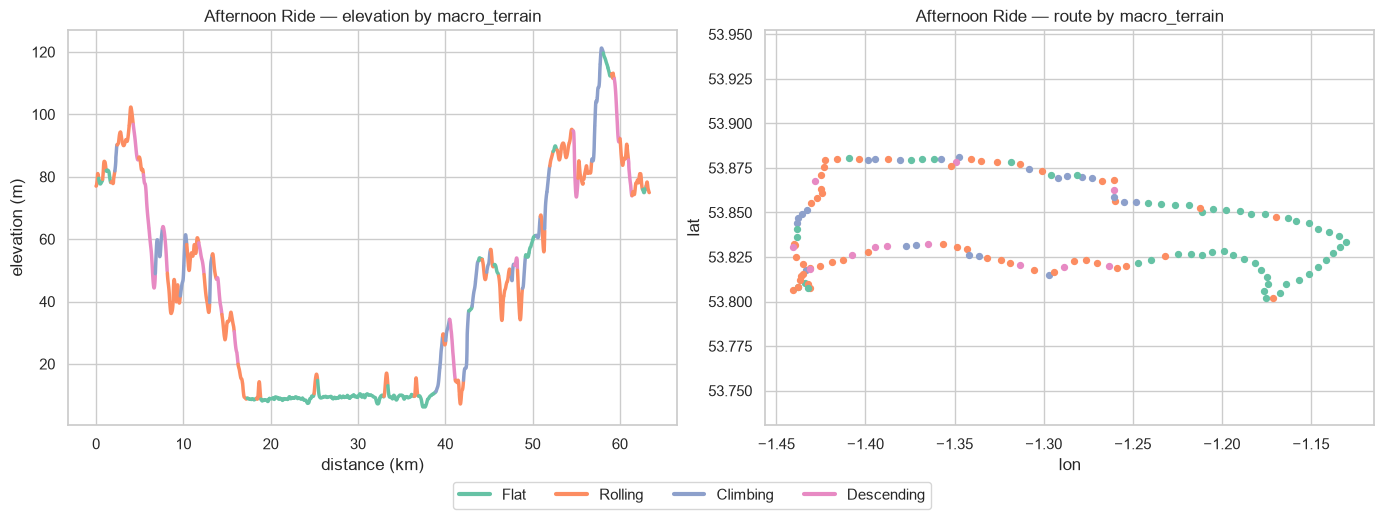

In [34]:
macro_palette = dict(zip(
    ["Flat", "Rolling", "Climbing", "Descending"],
    sns.color_palette("Set2", 4),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_ride_by(AFTERNOON_RIDE, "macro_terrain", macro_palette, axes[0], axes[1])

handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in macro_palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout()


### 16b. Where are the cautious/technical sections?

`macro_terrain` alone can't distinguish a smooth descent from a hairpin
one, or a steady climb from a stop-start one — that's exactly what
section 9c's `raw_label` adds. Highlighting just the three
cautious/technical categories against a muted "Other" shows where on
this specific ride they actually occur.


technical_highlight
Other                              124
Technical / interrupted descent      8
Technical / interrupted climb        7
Name: count, dtype: int64


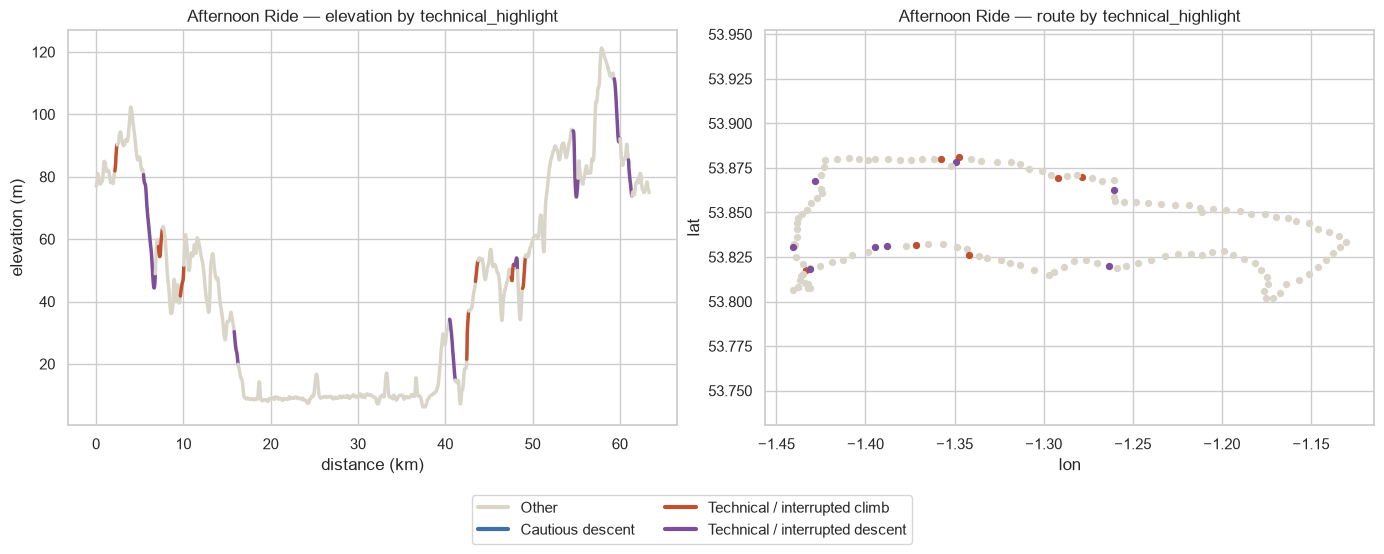

In [35]:
CAUTIOUS_TECHNICAL = ["Cautious descent", "Technical / interrupted climb", "Technical / interrupted descent"]

combined["technical_highlight"] = combined["raw_label"].where(
    combined["raw_label"].isin(CAUTIOUS_TECHNICAL), "Other"
)

technical_palette = {
    "Other": "#d9d5c9",
    "Cautious descent": "#3f6fa8",
    "Technical / interrupted climb": "#c1502f",
    "Technical / interrupted descent": "#7d4f9a",
}

print(combined[combined["ride"] == AFTERNOON_RIDE]["technical_highlight"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_ride_by(AFTERNOON_RIDE, "technical_highlight", technical_palette, axes[0], axes[1])

handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in technical_palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()


## Summary

Run this notebook top-to-bottom, then look at:

- Section 8/9's centroid table — the actual discovered categories and
  their defining feature values.
- Section 10's Adjusted Rand Index — how robust those categories are to
  a completely different (nonlinear, PyTorch-learned) representation.
- Section 11's plots — whether the categories visually make sense against
  real elevation profiles and routes.
- Section 13's plots — whether a *planned route*, with no ride data at
  all, can be given a useful preview of likely cardio/strength/technical
  sections using geometry alone.
- Section 14's Etape case study — checking that route-only prediction
  against real recorded outcomes on the same roads, and showing that its
  main blind spot isn't a fixable modelling gap but duration/fatigue:
  the same climb rides completely differently depending on how depleted
  the rider already is, which no route file can ever encode.
- Section 15 — testing whether temperature explains either of section
  14's findings. It doesn't explain the predicted-vs-actual mismatch
  (the one significant relationship runs backwards), and only partially
  explains the fatigue signature (a clean heat-stress story in 2023, no
  clear link to 2022's specific cadence collapse).
- Section 16's single-ride case study — the same elevation/route plot
  pair used throughout the notebook, applied once to a plain macro
  terrain split (flat/rolling/climbing/descending) and once to just the
  cautious/technical sections highlighted against everything else.

If a genuinely new, useful category shows up consistently (e.g. "flat
with obstacles" as its own stable cluster, distinct from "flat, steady"),
that's a candidate for a follow-up: either a second classification pass
in the main app's pipeline, or a new highlight type in the report.
